## SHAP
### Yilin Luo

### Introduction

In this assignment, we conducted a comprehensive interpretability analysis of a Random Forest model developed to predict loan default probability using a dataset of loan application and credit behavior variables. Our objective was not only to assess the predictive performance of the model but also to understand why it made certain predictions for individual applicants. To achieve this, we applied multiple SHAP-based interpretability techniques, including global feature importance (bar plots and impact direction plots), SHAP summary plots, dependence plots for key features, SHAP interaction plots, and individual-level explanations through force plots and waterfall plots. These visualizations allowed us to examine both the overall drivers of model predictions across the dataset and the personalized reasoning behind specific predictions, providing transparency for decision-making and compliance with explainability requirements in credit risk modeling.

### 1. Load and Prepare Data

In [231]:
import pandas as pd
import numpy as np
import plotly
np.random.seed(0)
import matplotlib.pyplot as plt

In [232]:
path = '/Users/yilin/Downloads'
df =  pd.read_csv(path + "/XYZloan_default_llm.csv")

In [233]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 32 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  16000 non-null  int64  
 1   Unnamed: 0    16000 non-null  int64  
 2   AP001         16000 non-null  int64  
 3   AP002         16000 non-null  int64  
 4   AP003         16000 non-null  int64  
 5   AP006         16000 non-null  object 
 6   AP007         16000 non-null  int64  
 7   AP008         16000 non-null  int64  
 8   CR004         16000 non-null  int64  
 9   CR009         16000 non-null  int64  
 10  CR015         16000 non-null  int64  
 11  CR017         16000 non-null  int64  
 12  CR018         16000 non-null  int64  
 13  CR019         16000 non-null  int64  
 14  MB005         15441 non-null  float64
 15  MB007         16000 non-null  object 
 16  PA022         15918 non-null  float64
 17  PA023         15918 non-null  float64
 18  PA028         15918 non-nu

In [234]:
# assign new column name using variables dictionary
columns = {
    'AP001': 'YR_AGE',
    'AP002': 'CODE_GENDER',
    'AP003': 'CODE_EDUCATION',
    'AP006': 'OS_TYPE',
    'AP007': 'LEVEL_APPL_CITY',
    'AP008': 'FLAG_IP_CITY_NOT_APPL_CITY',
    'CR004': 'CNT_QUERY_TIME_LAST_1MON',
    'CR009': 'AMT_LOAN_TOTAL',
    'CR015': 'MONTH_CREDIT_CARD_MOB_MAX',
    'CR017': 'SCORE_DEBIT_CARD_TOTAL_AMT',
    'CR018': 'SCORE_DEBIT_CARD_UTILITY_AMT',
    'CR019': 'SCORE_SINGLE_DEBIT_CARD_LIMIT',
    'MB005': 'YR_PHONE_ACTIVE',
    'MB007': 'Application_Device',
    'PA022': 'DAYS_BTW_APP_AND_FIRST_COLLECTION_OR_HIGH_RISK_CALL',
    'PA023': 'DAYS_BTW_APP_AND_FIRST_COLLECTION_CALL',
    'PA028': 'AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS',
    'PA029': 'AVG_LEN_COLLECTION_OR_HIGH_RISK_INBOUND_CALLS',
    'PA031': 'AVG_LEN_COLLECTION_CALLS',
    'TD001': 'TD_CNT_QUERY_LAST_7Day_P2P',
    'TD002': 'TD_CNT_QUERY_LAST_7Day_SMALL_LOAN',
    'TD003': 'TD_CNT_QUERY_LAST_7Day_BANK',
    'TD004': 'TD_CNT_QUERY_LAST_7Day_OTHER',
    'TD005': 'TD_CNT_QUERY_LAST_1MON_P2P',
    'TD006': 'TD_CNT_QUERY_LAST_1MON_SMALL_LOAN',
    'TD007': 'TD_CNT_QUERY_LAST_1MON_BANK',
    'TD008': 'TD_CNT_QUERY_LAST_1MON_OTHER',
    'TD009': 'TD_CNT_QUERY_LAST_3MON_P2P',
    'TD010': 'TD_CNT_QUERY_LAST_3MON_SMALL_LOAN',
    'TD011': 'TD_CNT_QUERY_LAST_3MON_BANK',
    'TD012': 'TD_CNT_QUERY_LAST_3MON_OTHER',
    'TD013': 'TD_CNT_QUERY_LAST_6MON_P2P',
    'TD014': 'TD_CNT_QUERY_LAST_6MON_SMALL_LOAN',
    'TD015': 'TD_CNT_QUERY_LAST_6MON_BANK',
    'TD016': 'TD_CNT_QUERY_LAST_6MON_OTHER',
    'TD022': 'TD_CNT_QUERY_LAST_24MON_SMALL_LOAN',
    'TD024': 'TD_CNT_QUERY_LAST_24MON_OTHER',
    'loan_default': 'Loan_Default',
    
}

# apply to your DataFrame
df = df.rename(columns=columns)

In [235]:
# drop three unused columns
df = df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0', 'reason'])

In [236]:
df.head(3)

,YR_AGE,CODE_GENDER,CODE_EDUCATION,OS_TYPE,LEVEL_APPL_CITY,FLAG_IP_CITY_NOT_APPL_CITY,CNT_QUERY_TIME_LAST_1MON,AMT_LOAN_TOTAL,MONTH_CREDIT_CARD_MOB_MAX,SCORE_DEBIT_CARD_TOTAL_AMT,...,TD_CNT_QUERY_LAST_7Day_P2P,TD_CNT_QUERY_LAST_1MON_P2P,TD_CNT_QUERY_LAST_1MON_SMALL_LOAN,TD_CNT_QUERY_LAST_3MON_P2P,TD_CNT_QUERY_LAST_3MON_SMALL_LOAN,TD_CNT_QUERY_LAST_6MON_P2P,TD_CNT_QUERY_LAST_6MON_SMALL_LOAN,TD_CNT_QUERY_LAST_24MON_SMALL_LOAN,TD_CNT_QUERY_LAST_24MON_OTHER,Loan_Default
0,33,1,3,h5,4,3,4,63100,6,8,...,2,4,1,4,1,4,1,10.0,0.0,1
1,34,1,3,h5,5,5,3,53370,3,8,...,2,3,1,6,2,7,2,15.0,10.0,1
2,36,2,1,ios,2,2,3,5400,5,8,...,4,4,2,4,2,5,2,25.0,0.0,1


In [237]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 29 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   YR_AGE                                               16000 non-null  int64  
 1   CODE_GENDER                                          16000 non-null  int64  
 2   CODE_EDUCATION                                       16000 non-null  int64  
 3   OS_TYPE                                              16000 non-null  object 
 4   LEVEL_APPL_CITY                                      16000 non-null  int64  
 5   FLAG_IP_CITY_NOT_APPL_CITY                           16000 non-null  int64  
 6   CNT_QUERY_TIME_LAST_1MON                             16000 non-null  int64  
 7   AMT_LOAN_TOTAL                                       16000 non-null  int64  
 8   MONTH_CREDIT_CARD_MOB_MAX                            16000 non-nul

In [238]:
# Identify all object-dtype columns as categorical
cat_var = df.select_dtypes(include=['object']).columns.tolist()

# Identify all numeric columns (int64 & float64) as numeric
num_var = df.select_dtypes(include=['number']).columns.tolist()

# Remove the target from num_var (if it’s numeric)
target = 'Loan_Default'
if target in num_var:
    num_var.remove(target)

# Combine
X_vars = cat_var + num_var

In [239]:
# Verify
print("Categorical variables:", cat_var)

Categorical variables: ['OS_TYPE', 'Application_Device']


In [240]:
print("Numeric variables:", num_var)

Numeric variables: ['YR_AGE', 'CODE_GENDER', 'CODE_EDUCATION', 'LEVEL_APPL_CITY', 'FLAG_IP_CITY_NOT_APPL_CITY', 'CNT_QUERY_TIME_LAST_1MON', 'AMT_LOAN_TOTAL', 'MONTH_CREDIT_CARD_MOB_MAX', 'SCORE_DEBIT_CARD_TOTAL_AMT', 'SCORE_DEBIT_CARD_UTILITY_AMT', 'SCORE_SINGLE_DEBIT_CARD_LIMIT', 'YR_PHONE_ACTIVE', 'DAYS_BTW_APP_AND_FIRST_COLLECTION_OR_HIGH_RISK_CALL', 'DAYS_BTW_APP_AND_FIRST_COLLECTION_CALL', 'AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS', 'AVG_LEN_COLLECTION_OR_HIGH_RISK_INBOUND_CALLS', 'AVG_LEN_COLLECTION_CALLS', 'TD_CNT_QUERY_LAST_7Day_P2P', 'TD_CNT_QUERY_LAST_1MON_P2P', 'TD_CNT_QUERY_LAST_1MON_SMALL_LOAN', 'TD_CNT_QUERY_LAST_3MON_P2P', 'TD_CNT_QUERY_LAST_3MON_SMALL_LOAN', 'TD_CNT_QUERY_LAST_6MON_P2P', 'TD_CNT_QUERY_LAST_6MON_SMALL_LOAN', 'TD_CNT_QUERY_LAST_24MON_SMALL_LOAN', 'TD_CNT_QUERY_LAST_24MON_OTHER']


In [241]:
print("Target:", target)

Target: Loan_Default


In [242]:
df[target].value_counts()

Loan_Default
0    12924
1     3076
Name: count, dtype: int64

### Train-Test Split

In [243]:
# split the data (70% of the data for training and 30% for testing)
X = df.drop(target, axis=1)
y = df[target]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
[X_train.shape,X_test.shape, y_train.shape, y_test.shape]

[(12000, 28), (4000, 28), (12000,), (4000,)]

### Target/mean encoding (Feature enhancement for the categorical variables)¶

In [244]:
from category_encoders import target_encoder as te
ec = te.TargetEncoder()

X_train_m = pd.DataFrame()
X_test_m = pd.DataFrame()

for var in cat_var:
    X_train_m[var+'_D'] = ec.fit_transform(X_train[var],y_train)
    X_test_m[var+'_D'] = ec.transform(X_test[var])

X_train_m

,OS_TYPE_D,Application_Device_D
8928,0.188905,0.189318
9895,0.188905,0.189318
14163,0.220118,0.245247
14352,0.180544,0.164782
15916,0.180544,0.178959
...,...,...
13123,0.188905,0.189318
3264,0.188905,0.189318
9845,0.188905,0.189318
10799,0.180544,0.178959


### Perform mean imputation for missing values on continuous variables

In [245]:
# Provide the code to check the variables that have missing value.
# Get the means from the training data
# Apply the means to the train data
# Apply the means to the test data

# Check 
# Find columns with missing values for the numerical columns
X_train_numvar = X_train[num_var]
missing_columns = X_train_numvar.columns[X_train_numvar.isnull().sum() > 0]

# Display the columns with missing values
missing_columns

Index(['YR_PHONE_ACTIVE',
       'DAYS_BTW_APP_AND_FIRST_COLLECTION_OR_HIGH_RISK_CALL',
       'DAYS_BTW_APP_AND_FIRST_COLLECTION_CALL',
       'AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS',
       'AVG_LEN_COLLECTION_OR_HIGH_RISK_INBOUND_CALLS',
       'AVG_LEN_COLLECTION_CALLS', 'TD_CNT_QUERY_LAST_24MON_SMALL_LOAN',
       'TD_CNT_QUERY_LAST_24MON_OTHER'],
      dtype='object')

In [246]:
for col in missing_columns:
    # Calculate the mean of the column (ignoring NaNs)
    mean_value = X_train[col].mean()
    
    # Impute the missing values in both X_train and X_test
    X_train[col].fillna(mean_value, inplace=True)
    X_test[col].fillna(mean_value, inplace=True)

In [247]:
#Modeling data
X_train_model = pd.concat([X_train_m, X_train[num_var]], axis=1)
X_train_model.shape

X_test_model = pd.concat([X_test_m, X_test[num_var]], axis=1)
[X_train_model.shape, X_test_model.shape]

[(12000, 28), (4000, 28)]

### 2. Build the Fine-tune the Decision Tree Model

In [248]:
# if y_train is a numpy array, wrap in a Series first
y = pd.Series(y_train)

# compute the counts sorted by class label, name the Series “Count”
count_series = y.value_counts().sort_index().rename("Count")

# turn it into a one-column DataFrame
count_df = count_series.to_frame()

print(count_df)

              Count
Loan_Default       
0              9670
1              2330


In [249]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier # for classification
from sklearn.tree import DecisionTreeRegressor # for regression

# Define the parameter distributions
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [5, 10, 20],
    'min_samples_split': [10, 20, 50],
    'criterion': ['gini', 'entropy']
}

dtree = DecisionTreeClassifier(random_state=42,class_weight='balanced')

# Set up the randomized search
random_search = RandomizedSearchCV(
    estimator=dtree,
    param_distributions=param_grid,
    n_iter=20,              # Number of parameter settings sampled
    scoring='roc_auc',     # Metric to optimize
    cv=5,                   # 5-fold cross-validation
    random_state=42,
    n_jobs=-1               # Use all CPU cores
)

# Fit the search to training data
random_search.fit(X_train_model, y_train)

RandomizedSearchCV(cv=5,
                   estimator=DecisionTreeClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 5, 7, 10, None],
                                        'min_samples_leaf': [5, 10, 20],
                                        'min_samples_split': [10, 20, 50]},
                   random_state=42, scoring='roc_auc')

In [250]:
# Get the best model
best_dtree_model = random_search.best_estimator_

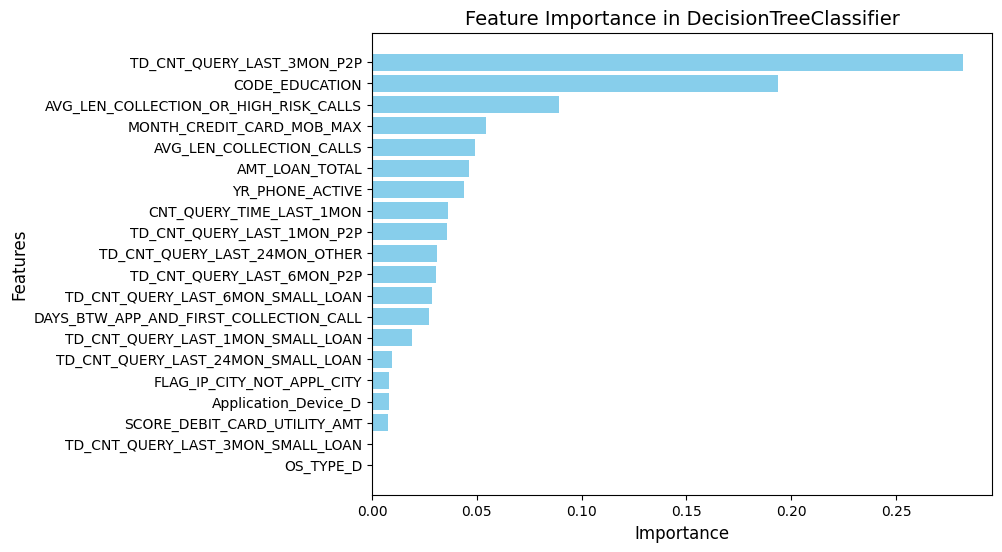

In [251]:
# Get feature importances
# Create a DataFrame for visualization
# Plot the feature importance chart

importances = best_dtree_model.feature_importances_
feature_names = X_train_model.columns
# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)[0:20]

plt.figure(figsize=(8, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance in DecisionTreeClassifier', fontsize=14)
plt.gca().invert_yaxis()  # Optional: Show the most important features on top
plt.show()

### 3. Build the Scikit-learn Random Forest Model Based on the Top 10 Features

In Section 3, we will select the top 10 variables identified from the Random Forest model above and use them to train a new Random Forest model with scikit-learn. Before we get started, let's use mean encoding to deal with missing values in these features.

### Mean Imputation for Top 10 Features

In [254]:
# Top 10 features
top_10_features = [
    'TD_CNT_QUERY_LAST_3MON_P2P',
    'CODE_EDUCATION',
    'AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS',
    'MONTH_CREDIT_CARD_MOB_MAX',
    'AVG_LEN_COLLECTION_CALLS',
    'AMT_LOAN_TOTAL',
    'YR_PHONE_ACTIVE',
    'CNT_QUERY_TIME_LAST_1MON',
    'TD_CNT_QUERY_LAST_1MON_P2P',
    'TD_CNT_QUERY_LAST_24MON_OTHER'
]

# Impute missing values with column mean
for col in top_10_features:
    mean_value = df[col].mean()
    df[col].fillna(mean_value, inplace=True)

# Check if any missing values remain
print(df[top_10_features].isnull().sum())

TD_CNT_QUERY_LAST_3MON_P2P               0
CODE_EDUCATION                           0
AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS    0
MONTH_CREDIT_CARD_MOB_MAX                0
AVG_LEN_COLLECTION_CALLS                 0
AMT_LOAN_TOTAL                           0
YR_PHONE_ACTIVE                          0
CNT_QUERY_TIME_LAST_1MON                 0
TD_CNT_QUERY_LAST_1MON_P2P               0
TD_CNT_QUERY_LAST_24MON_OTHER            0
dtype: int64


### Build the scikit-learn random forest model

In [255]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.ensemble import RandomForestRegressor

Y = df['Loan_Default']
X = df[['TD_CNT_QUERY_LAST_3MON_P2P', 'CODE_EDUCATION', 'AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS', 
          'MONTH_CREDIT_CARD_MOB_MAX', 'AVG_LEN_COLLECTION_CALLS', 'AMT_LOAN_TOTAL',
          'YR_PHONE_ACTIVE', 'CNT_QUERY_TIME_LAST_1MON', 'TD_CNT_QUERY_LAST_1MON_P2P',
          'TD_CNT_QUERY_LAST_24MON_OTHER']]

In [256]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2)

In [257]:
model = RandomForestRegressor(max_depth=6, random_state=0, n_estimators=10)
model.fit(X_train, Y_train)  
print(model.feature_importances_)

[0.14177846 0.11715027 0.1145278  0.07525932 0.10336243 0.13578657
 0.07097903 0.01505793 0.16311788 0.06298028]


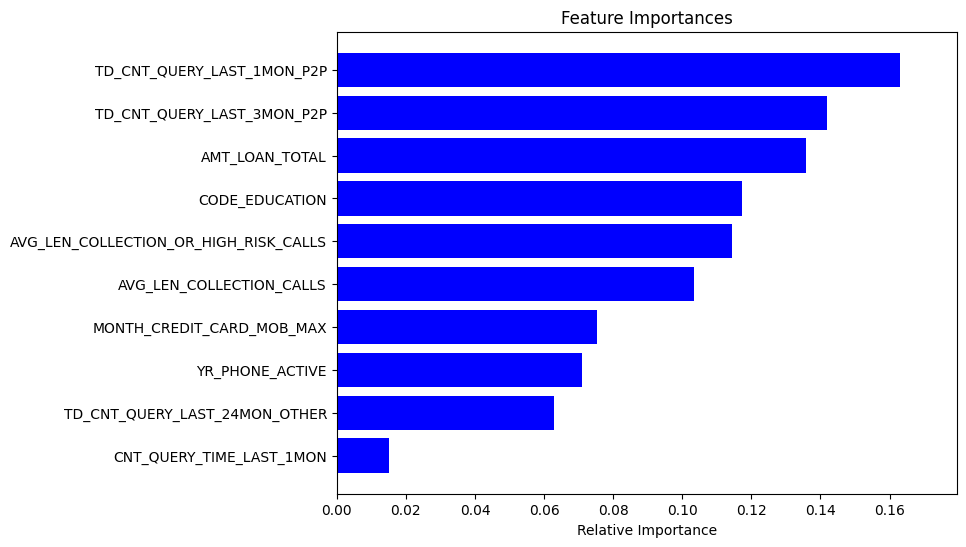

In [258]:
importances = model.feature_importances_
indices = np.argsort(importances)

features = X_train.columns
plt.figure(figsize=(8,6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')

# Adjust X-axis to make small values visible
plt.xlim(0, max(importances) * 1.1)

plt.show()

### 4. SHAP Plots

Before plotting the SHAP values, we first review the meaning of each column in the dataset, focusing on variables related to loan applications and credit behavior. It could also help us understand the following plots.

- **CODE_EDUCATION** – Encoded education level of the applicant (e.g., high school, bachelor’s, master’s, etc.), usually represented numerically for modeling.
- **TD_CNT_QUERY_LAST_1MON_P2P** – Number of peer-to-peer (P2P) loan credit inquiries in the last 1 month.
- **TD_CNT_QUERY_LAST_24MON_OTHER** – Number of “other” type loan or credit product inquiries in the last 24 months.
- **TD_CNT_QUERY_LAST_3MON_P2P** – Number of P2P loan credit inquiries in the last 3 months.
- **AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS** – Average length of phone calls from collection agencies or high-risk contacts, likely measured in seconds.
- **AVG_LEN_COLLECTION_CALLS** – Average length of all collection calls (not just high-risk), measured in seconds.
- **MONTH_CREDIT_CARD_MOB_MAX** – Maximum “Months on Book” (account age) among the applicant’s credit cards.
- **AMT_LOAN_TOTAL** – Total loan amount applied for or outstanding.
- **YR_PHONE_ACTIVE** – Number of years the applicant’s phone number has been active (proxy for stability).
- **CNT_QUERY_TIME_LAST_1MON** – Count of all credit inquiries in the last 1 month, regardless of loan type.

### 4.1 Summary Plot

In [259]:
# !pip install shap

In [260]:
import shap

In [261]:
shap_values = shap.TreeExplainer(model).shap_values(X_train)

/var/folders/jw/8vx4z7591_3bjf22j5ggvycc0000gn/T/ipykernel_19156/2901259419.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)


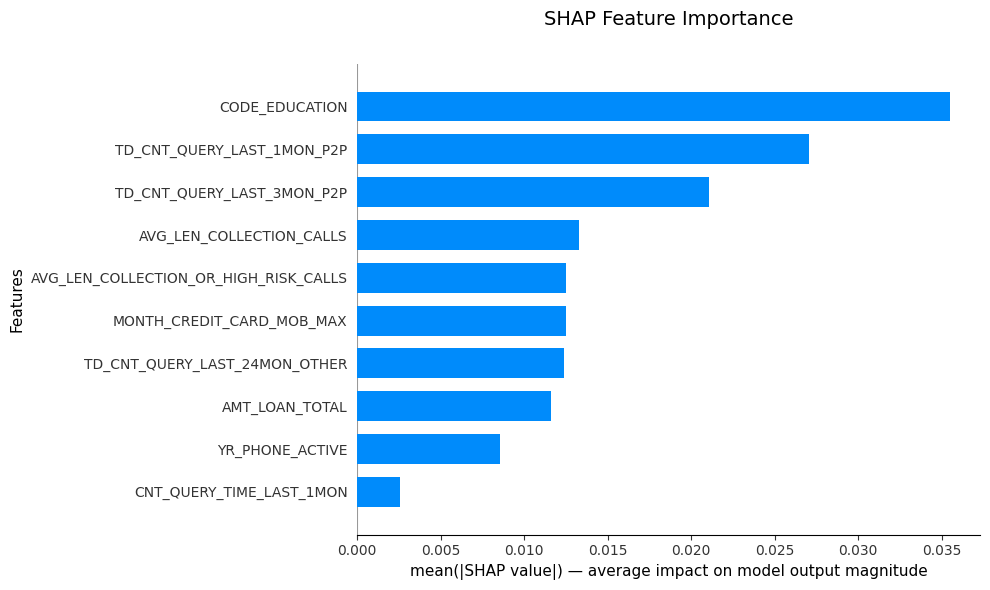

In [262]:
# SHAP bar plot with layout/title designed
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.gcf().set_size_inches(10, 6)
plt.title(f"SHAP Feature Importance\n", fontsize=14, pad=12)
plt.xlabel("mean(|SHAP value|) — average impact on model output magnitude", fontsize=11)
plt.ylabel("Features", fontsize=11)
plt.xticks(fontsize=10); plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

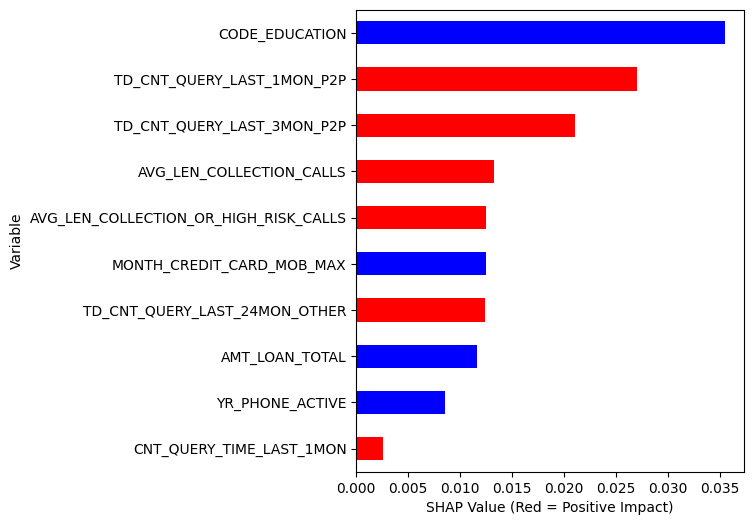

In [263]:
def ABS_SHAP(df_shap, df):

    # If df_shap is a SHAP Explanation object, get the underlying array
    if hasattr(df_shap, "values"):
        df_shap = df_shap.values

    # If it's a NumPy array, convert with feature names
    if isinstance(df_shap, np.ndarray):
        shap_v = pd.DataFrame(df_shap, columns=df.columns)
    else:
        shap_v = pd.DataFrame(df_shap)

    feature_list = df.columns
    df_v = df.copy().reset_index(drop=True)
    
    # Correlation for coloring
    corr_list = []
    for i in feature_list:
        try:
            b = np.corrcoef(shap_v[i], df_v[i])[1][0]
        except Exception:
            b = 0
        corr_list.append(b)

    corr_df = pd.DataFrame({"Variable": feature_list, "Corr": corr_list}).fillna(0)
    corr_df["Sign"] = np.where(corr_df["Corr"] > 0, "red", "blue")
    
    # Absolute SHAP mean values
    shap_abs = np.abs(shap_v)
    k = pd.DataFrame({"Variable": feature_list, "SHAP_abs": shap_abs.mean()})
    
    # Merge & sort
    k2 = k.merge(corr_df, on="Variable", how="inner")
    k2 = k2.sort_values(by="SHAP_abs", ascending=True)
    colorlist = k2["Sign"]
    
    # Plot
    ax = k2.plot.barh(
        x="Variable",
        y="SHAP_abs",
        color=colorlist,
        figsize=(5, 6),
        legend=False
    )
    ax.set_xlabel("SHAP Value (Red = Positive Impact)")

# Example usage
ABS_SHAP(shap_values, X_train)

/var/folders/jw/8vx4z7591_3bjf22j5ggvycc0000gn/T/ipykernel_19156/3022310071.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train)


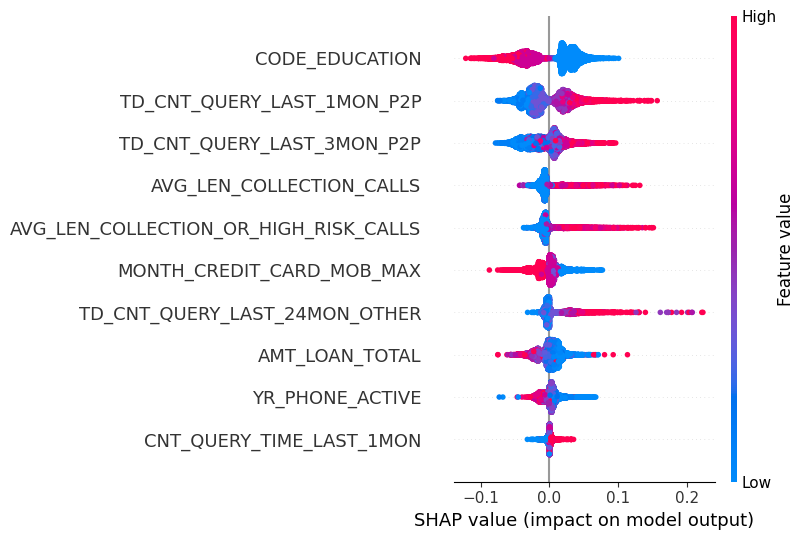

In [264]:
shap.summary_plot(shap_values, X_train)

### SHAP Summary Plot Explanation

The SHAP analysis provides a multi-dimensional understanding of how different features influence loan default predictions, capturing magnitude, direction, and distribution effects. In **the SHAP Feature Importance bar plot**, features are ranked by their mean absolute SHAP value, reflecting the average contribution of each variable to the model’s predictions. CODE_EDUCATION (applicant’s education level) is the strongest predictor, followed by TD_CNT_QUERY_LAST_1MON_P2P (number of peer-to-peer loan inquiries in the last month) and TD_CNT_QUERY_LAST_3MON_P2P (number of peer-to-peer inquiries in the last three months). The length of each bar indicates total predictive impact regardless of whether the feature increases or decreases default risk, offering a model-agnostic complement to tree-based feature importance metrics.

**The SHAP Feature Importance with Impact Direction plot** adds interpretability by separating positive (red) and negative (blue) impacts on predicted default probability. For example, higher TD_CNT_QUERY_LAST_1MON_P2P values tend to increase default risk, whereas higher CODE_EDUCATION levels typically reduce it. This directional breakdown helps clarify not only which features are most influential but also how changing these feature values can shift default likelihood—critical for developing data-driven credit risk strategies.

Finally, **the SHAP Summary (bee swarm) plot** shows the distribution of feature impacts for individual applicants. Each point represents one borrower, with color indicating the feature value (red = high, blue = low) and horizontal position showing its SHAP value (impact magnitude and direction). For instance, high CODE_EDUCATION values cluster toward negative SHAP values, underscoring their protective role, while high TD_CNT_QUERY_LAST_1MON_P2P values cluster toward positive SHAP values, indicating higher default risk. This granular view reveals both the intensity and consistency of feature effects, enabling more precise segmentation of borrower risk profiles.

### 4.2 Dependence Plot

To understand how individual features influence the model’s predictions, we use SHAP dependence plots, which show the relationship between a feature’s value and its corresponding SHAP value across all observations in the dataset. Because SHAP values quantify a feature’s contribution to changes in the model’s output, these plots illustrate how variations in a feature affect predicted outcomes. Vertical dispersion at a given feature value reflects interaction effects with other variables, and to highlight these interactions, the plot automatically colors points by the value of another related feature. This approach provides deeper insight into both the direct and interaction effects of features on the model’s predictions.

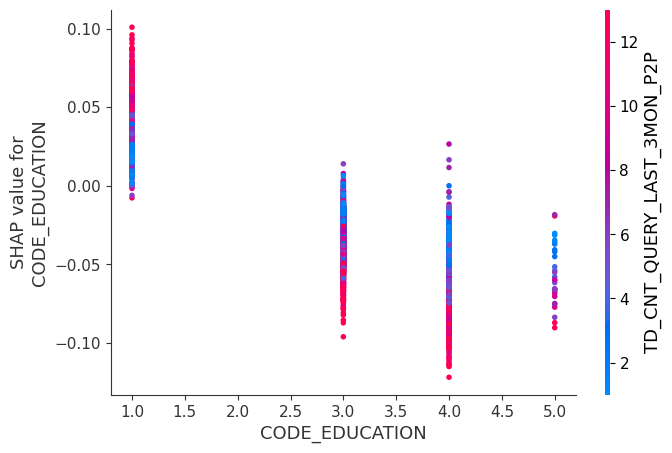

In [265]:
shap.dependence_plot("CODE_EDUCATION", shap_values, X_train)

Higher CODE_EDUCATION values generally have a negative SHAP impact, meaning higher education levels are associated with reduced default risk. The interaction color gradient shows that applicants with higher recent peer-to-peer loan queries (TD_CNT_QUERY_LAST_3MON_P2P) tend to have a less negative (or even slightly positive) impact, suggesting that frequent recent loan inquiries can offset the protective effect of higher education.

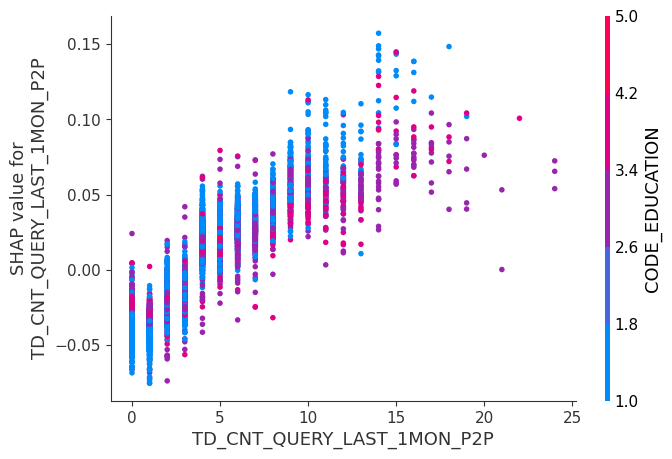

In [266]:
shap.dependence_plot("TD_CNT_QUERY_LAST_1MON_P2P", shap_values, X_train)

As the number of peer-to-peer loan inquiries in the last month increases, SHAP values rise sharply, indicating a higher predicted risk of default. The interaction shows that lower CODE_EDUCATION levels (blue) amplify this risk effect, while higher education levels (red) slightly mitigate it.

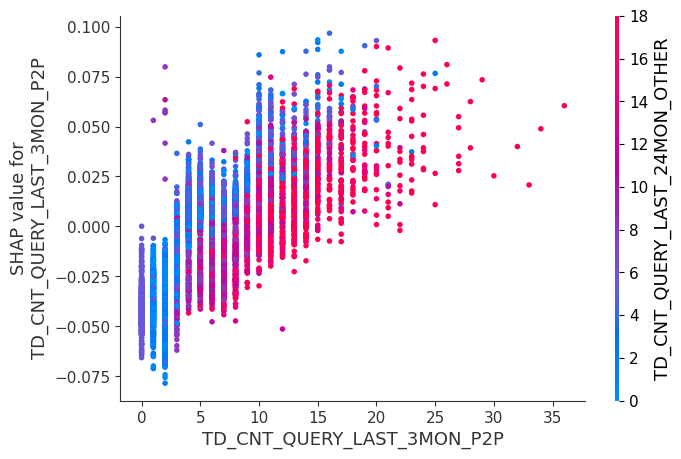

In [267]:
shap.dependence_plot("TD_CNT_QUERY_LAST_3MON_P2P", shap_values, X_train)

An increase in peer-to-peer loan queries over the last 3 months steadily raises the SHAP value, meaning higher predicted risk. Applicants with more other credit inquiries in the past 24 months (red) tend to have a stronger positive impact on risk, indicating a compounding effect between recent and long-term borrowing activity.

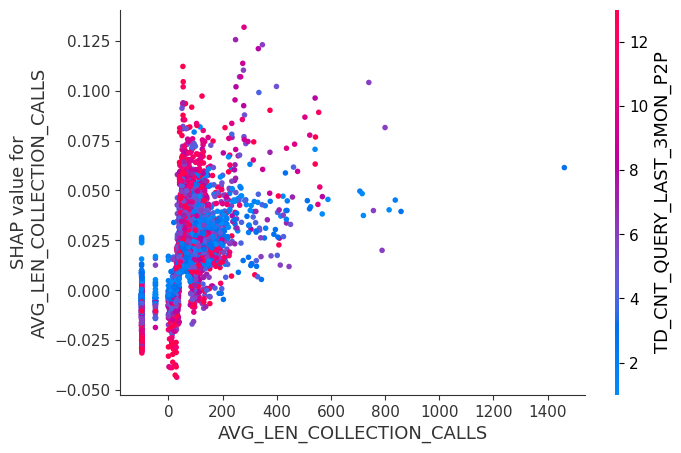

In [268]:
shap.dependence_plot("AVG_LEN_COLLECTION_CALLS", shap_values, X_train)

Longer average collection call durations are associated with higher SHAP values, suggesting increased default risk. The interaction reveals that lower education levels (blue) are more strongly associated with high-risk calls, while higher education levels (red) show a slightly dampened risk effect.

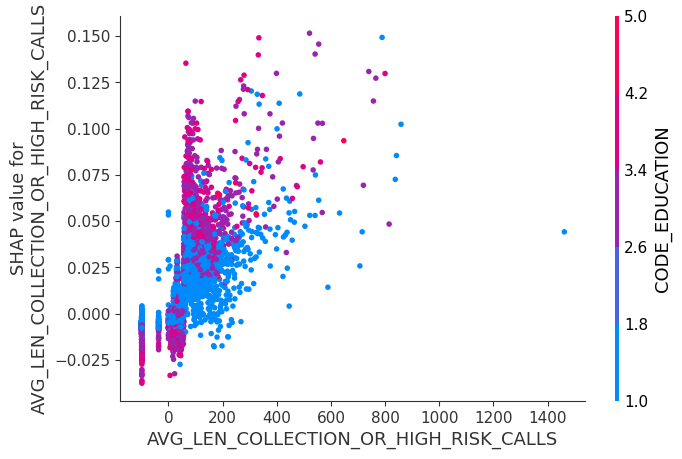

In [269]:
shap.dependence_plot("AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS", shap_values, X_train)

Similar to the previous metric, longer calls—especially those flagged as high risk—correlate with higher default predictions. Applicants with low education levels amplify the effect, while higher education reduces the magnitude of risk.

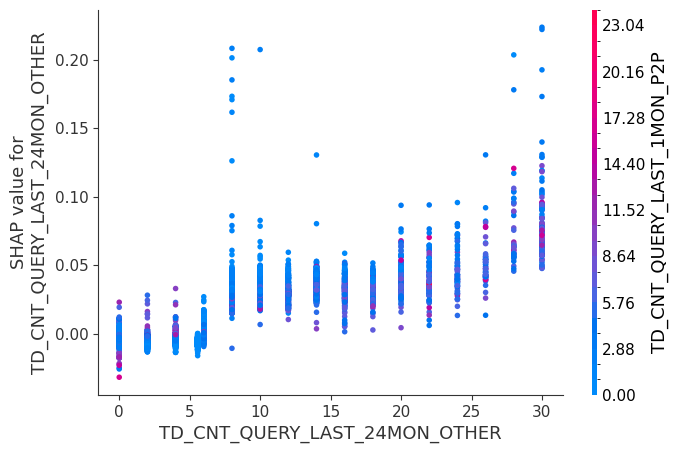

In [270]:
shap.dependence_plot("TD_CNT_QUERY_LAST_24MON_OTHER", shap_values, X_train)

More “other” loan inquiries in the past 24 months lead to steadily higher SHAP values, indicating greater risk. When recent peer-to-peer inquiries (TD_CNT_QUERY_LAST_1MON_P2P) are also high (red), the risk effect intensifies, highlighting a strong interaction between long-term and short-term borrowing behavior.

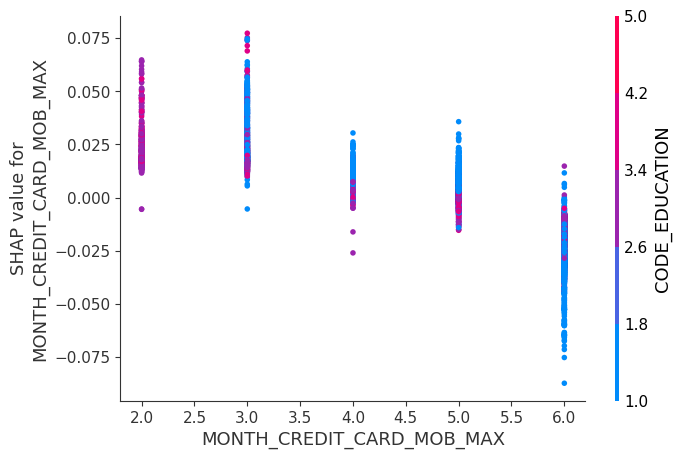

In [271]:
shap.dependence_plot("MONTH_CREDIT_CARD_MOB_MAX", shap_values, X_train)

Higher values (indicating longer months since maximum credit card balance) show a slightly positive SHAP value in some cases, but the effect is small and mixed. Applicants with higher education levels show slightly less variability in risk contribution.

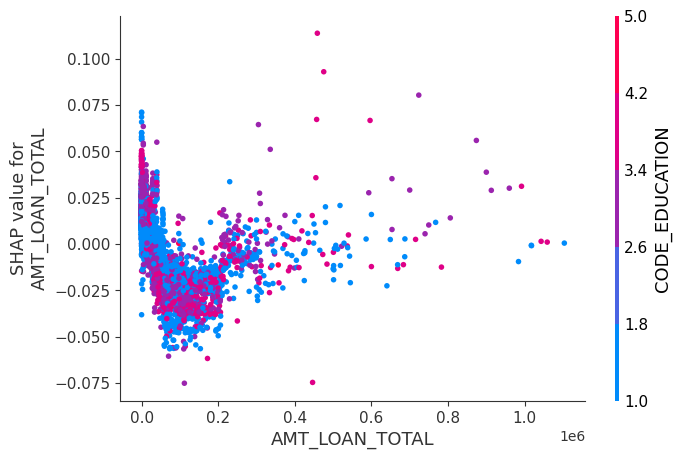

In [272]:
shap.dependence_plot("AMT_LOAN_TOTAL", shap_values, X_train)

Total loan amount shows a complex, non-linear effect. Very low or very high amounts tend to slightly increase predicted risk. Interaction shows that education moderates this relationship, with higher education levels generally linked to lower risk at similar loan amounts.

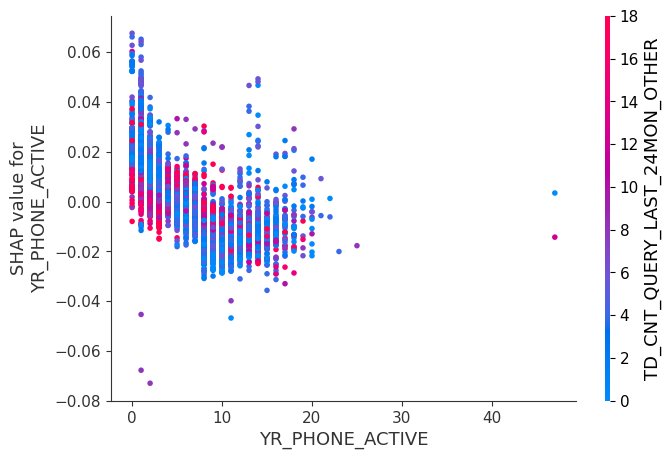

In [273]:
shap.dependence_plot("YR_PHONE_ACTIVE", shap_values, X_train)

More years with an active phone line generally correlate with lower SHAP values, suggesting reduced risk. However, if recent peer-to-peer inquiries are high (red), the protective effect is weakened.

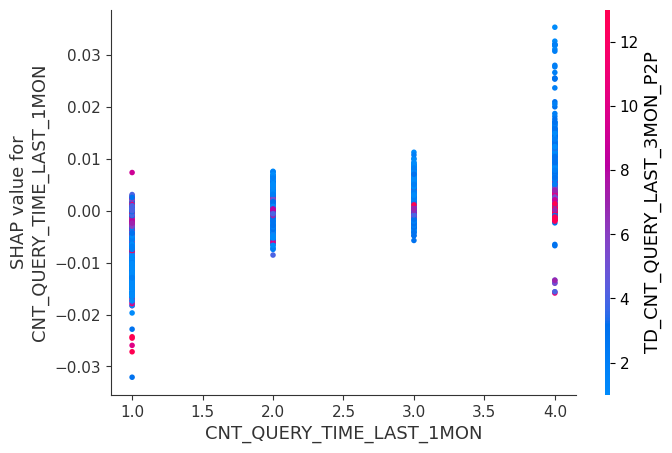

In [274]:
shap.dependence_plot("CNT_QUERY_TIME_LAST_1MON", shap_values, X_train)

Higher counts of credit queries in the last month are weakly associated with risk, but the effect is small. When paired with high recent peer-to-peer inquiries, the impact can be slightly more positive, indicating elevated risk.

/var/folders/jw/8vx4z7591_3bjf22j5ggvycc0000gn/T/ipykernel_19156/2219114974.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/opt/anaconda3/envs/Anomalydetection/lib/python3.12/site-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/opt/anaconda3/envs/Anomalydetection/lib/python3.12/site-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(

<Figure size 1400x800 with 0 Axes>

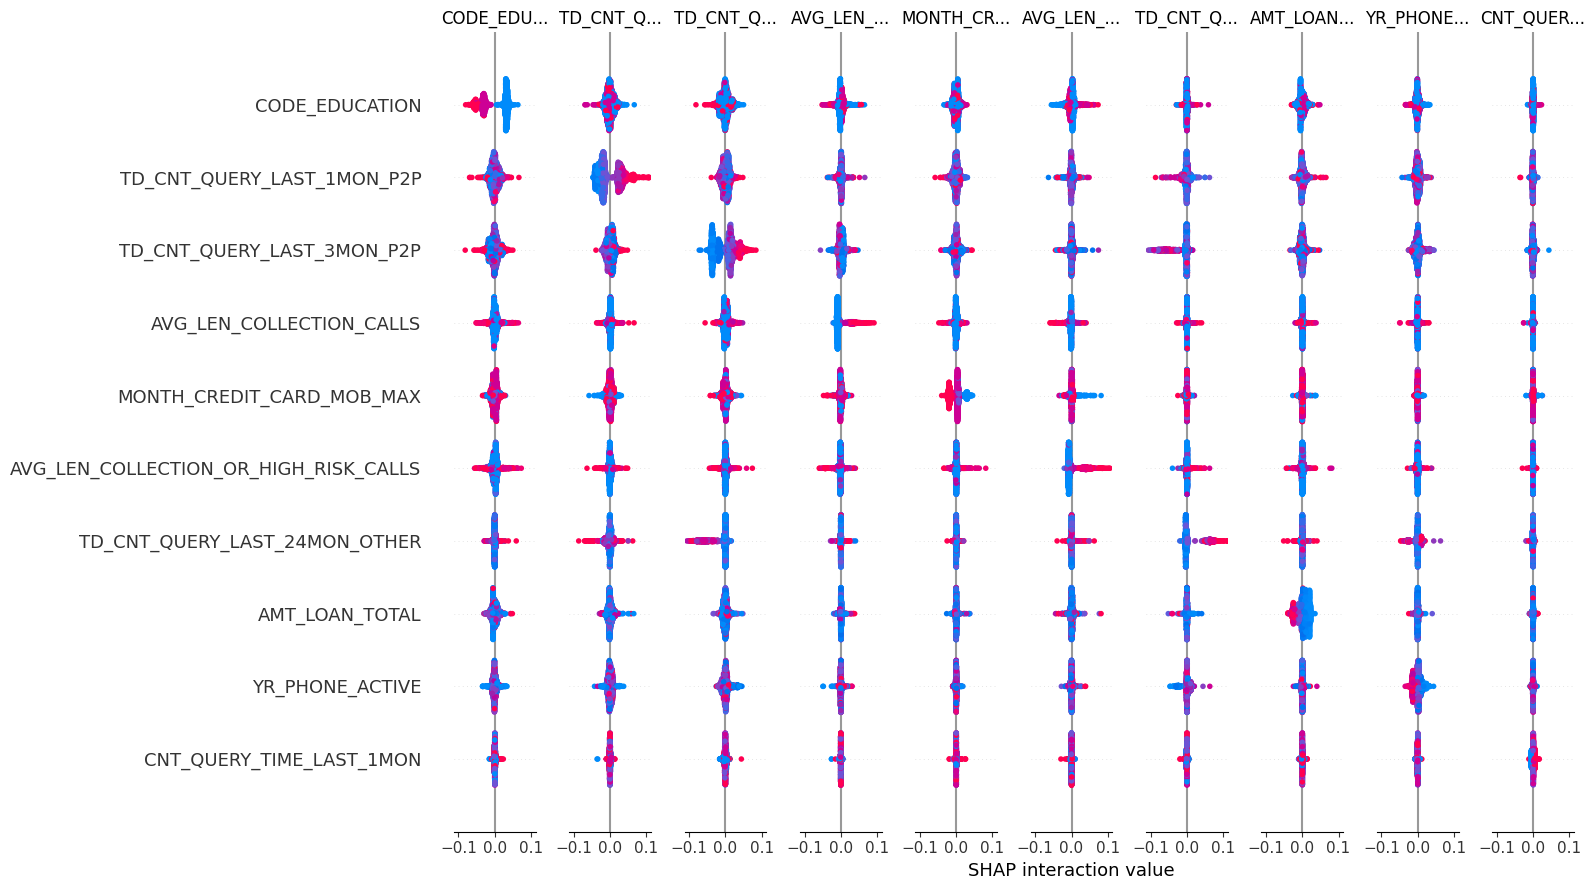

In [275]:
# Compute interaction SHAP values (use a subset for speed, keep your model)
X_plot = X_train.iloc[:2000, :].copy()
explainer = shap.TreeExplainer(model)
shap_inter = explainer.shap_interaction_values(X_plot)

# increase plot size & limit how many features are shown
plt.figure(figsize=(14, 8))  # wider canvas helps prevent overlap
shap.summary_plot(
    shap_inter,
    X_plot,
    plot_type="dot",
    max_display=10,          
    plot_size=(14, 8),       # SHAP's own size control (width, height)
    show=False
)

# Show the plot
plt.xticks(rotation=0)       
plt.tight_layout()
plt.show()

This SHAP interaction summary plot visualizes how pairs of features jointly influence the model’s loan default predictions. Each row represents a primary feature, while the columns correspond to interacting features, with the diagonal showing each feature’s interaction with itself (equivalent to its main effect). The colored “beeswarm” points indicate individual observations, where the color represents the feature value (red = high, blue = low) and the horizontal position shows the SHAP interaction value—positive values increase predicted default risk, negative values decrease it. The width and spread of points in a cell reflect the strength and variability of that interaction. For example, strong interactions along the CODE_EDUCATION–TD_CNT_QUERY_LAST_1MON_P2P cell suggest that the combined effect of education level and recent peer-to-peer loan inquiries meaningfully impacts risk predictions. This view helps identify not only important single features but also synergistic or mitigating effects between them, which can guide more nuanced credit risk strategies.

### 4.3 Force Plot

In [276]:
# Get the predictions and put them with the test data.
X_output = X_test.copy()
X_output.loc[:,'predict'] = np.round(model.predict(X_output),2)

# Randomly pick some observations
random_picks = np.arange(1,330,50) # Every 50 rows
S = X_output.iloc[random_picks]
S

,TD_CNT_QUERY_LAST_3MON_P2P,CODE_EDUCATION,AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS,MONTH_CREDIT_CARD_MOB_MAX,AVG_LEN_COLLECTION_CALLS,AMT_LOAN_TOTAL,YR_PHONE_ACTIVE,CNT_QUERY_TIME_LAST_1MON,TD_CNT_QUERY_LAST_1MON_P2P,TD_CNT_QUERY_LAST_24MON_OTHER,predict
8650,2,1,-98.0,3,-98.0,3000,2.0,1,0,8.0,0.14
3775,4,3,101.0,6,101.0,151500,21.0,3,4,0.0,0.19
8298,4,1,46.0,5,-98.0,0,5.0,2,2,6.0,0.23
13986,8,1,34.2,5,34.2,31951,6.0,2,4,12.0,0.25
9242,4,1,115.0,5,115.0,0,3.0,4,4,0.0,0.36
11370,2,1,-98.0,3,-98.0,0,6.0,1,2,0.0,0.15
7626,5,4,-98.0,5,-98.0,4879,5.0,3,2,6.0,0.12


The prediction table shows a subset of test set observations with both their feature values and the model’s predicted probability of default (predict). For example, the first observation has relatively low recent loan inquiry counts (TD_CNT_QUERY_LAST_1MON_P2P = 0, TD_CNT_QUERY_LAST_3MON_P2P = 2), moderate phone activity (YR_PHONE_ACTIVE = 2), and a small loan amount (AMT_LOAN_TOTAL = 3000), resulting in a relatively low predicted probability of 0.13. In contrast, rows with higher counts of recent peer-to-peer loan queries (TD_CNT_QUERY_LAST_1MON_P2P or TD_CNT_QUERY_LAST_3MON_P2P ≥ 4), high average collection call lengths, or zero current loan amount tend to have higher predictions (up to 0.36), indicating that the model associates these factors with greater default risk.

In [277]:
shap.initjs()

In [278]:

def shap_plot(j):
    explainerModel = shap.TreeExplainer(model)
    shap_values_Model = explainerModel.shap_values(S)
    p = shap.force_plot(explainerModel.expected_value, shap_values_Model[j], S.iloc[[j]])
    return(p)

In [279]:
X_train.mean()

TD_CNT_QUERY_LAST_3MON_P2P                   5.448984
CODE_EDUCATION                               2.006406
AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS      -35.881584
MONTH_CREDIT_CARD_MOB_MAX                    4.925469
AVG_LEN_COLLECTION_CALLS                   -47.711564
AMT_LOAN_TOTAL                           36018.451094
YR_PHONE_ACTIVE                              5.979733
CNT_QUERY_TIME_LAST_1MON                     2.507891
TD_CNT_QUERY_LAST_1MON_P2P                   3.634531
TD_CNT_QUERY_LAST_24MON_OTHER                5.577423
dtype: float64

The X_train mean row provides the average value of each feature in the training dataset, serving as a reference point for interpreting SHAP and force plots. For instance, the mean CODE_EDUCATION is around 2.01, so a value of 1 in the force plot is lower than average and may push predictions up or down depending on the feature’s learned relationship with default risk. Similarly, the mean TD_CNT_QUERY_LAST_3MON_P2P is about 5.45, meaning values much higher or lower in a given observation will contribute more strongly in SHAP explanations. This mean baseline is what the model uses to compute the base value for SHAP plots—feature deviations from these averages drive the differences between the base value and the actual prediction.

In [280]:
Y_test.mean()

0.1903125

In [281]:
shap_plot(0)

**Force Plot 1 (Prediction = 0.14):**

The base value for this observation is approximately 0.19, meaning that without any feature information, the model would predict a default probability of 0.19. The actual prediction is lower at 0.14, indicating that the net effect of the features pulls the score down. The largest negative contributions (blue) come from features like TD_CNT_QUERY_LAST_1MON_P2P = 0, YR_PHONE_ACTIVE = 2, and TD_CNT_QUERY_LAST_3MON_P2P = 2, all of which push the probability well below the base value. On the positive side (red), CODE_EDUCATION = 1 and TD_CNT_QUERY_LAST_24MON_OTHER = 8 slightly increase the default probability, but their effect is outweighed by the negative contributions.


In [282]:
shap_plot(1)

**Force Plot 2 (Prediction = 0.19):**

Here, the base value is also around 0.19, and the final prediction remains unchanged at 0.19, suggesting that positive and negative forces balance out. Strong positive contributions include TD_CNT_QUERY_LAST_1MON_P2P = 4 and AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS = 101, both pushing the score upward. However, negative contributions from CODE_EDUCATION = 3, MONTH_CREDIT_CARD_MOB_MAX = 6, and a large loan amount (AMT_LOAN_TOTAL ≈ 151,500) counteract the upward push, keeping the final prediction equal to the baseline.

In [283]:
shap_plot(2)

**Force Plot 3 (Prediction = 0.23):**

The base value is about 0.19, but the final score rises to 0.23 due to several strong positive influences. Key upward drivers include MONTH_CREDIT_CARD_MOB_MAX = 5, TD_CNT_QUERY_LAST_3MON_P2P = 4, and AMT_LOAN_TOTAL = 0 (possibly indicating risk in absence of a current loan). CODE_EDUCATION = 1 also contributes positively. Negative influence is primarily from TD_CNT_QUERY_LAST_1MON_P2P = 2 and AVG_LEN_COLLECTION_CALLS, which slightly offset the increase, but not enough to prevent a higher-than-baseline prediction.

In [284]:
shap_plot(3)

**Force Plot 4 (Prediction = 0.25):**

With a base value of about 0.19, this case’s prediction climbs to 0.25, reflecting a strong net positive push. The largest contributors are AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS = 34.2, TD_CNT_QUERY_LAST_24MON_OTHER = 12, and CODE_EDUCATION = 1, all strongly associated with higher default risk in the model. Negative forces from TD_CNT_QUERY_LAST_3MON_P2P = 8 and YR_PHONE_ACTIVE slightly temper the increase but are overshadowed by the magnitude of the positive contributions.

### 4.4 Waterfall Plot

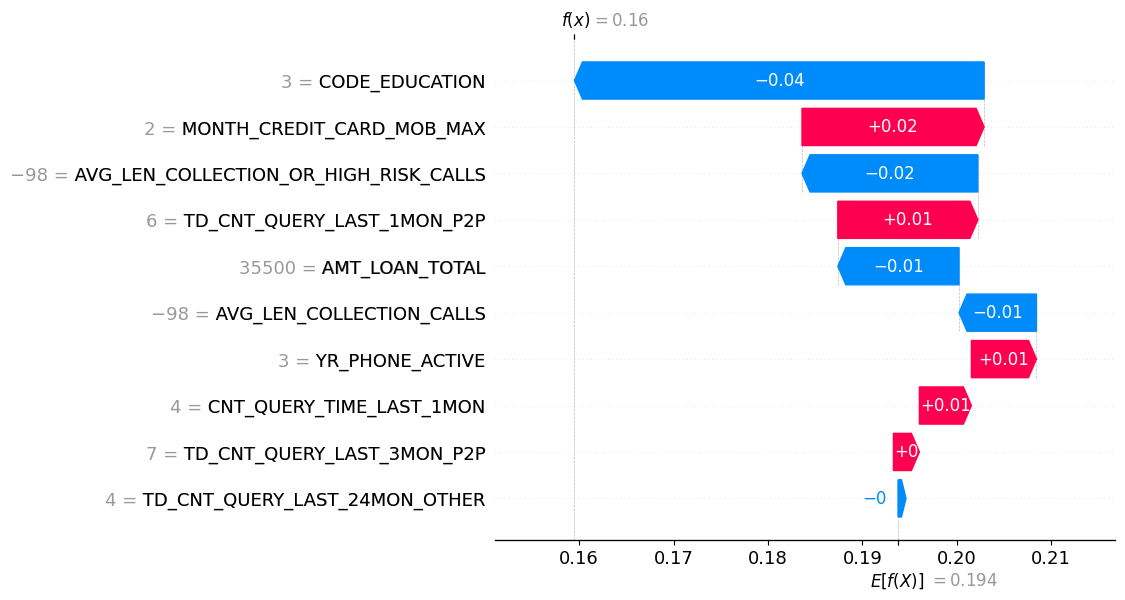

In [285]:
import shap
explainer = shap.Explainer(model)
rf_shap_values = explainer(X_train)
shap.plots.waterfall(rf_shap_values[0]) 

**Waterfall Plot 1 (f(x) = 0.16):**

The model’s base value (E[f(X)]) is 0.194, meaning without any feature information, the predicted default probability would be around 19.4%. The actual prediction dropped to 15.7% due to several strong negative contributions. CODE_EDUCATION = 3 (-0.04) and AVG_LEN_COLLECTION_OR_HIGH_RISK_CALLS = -98 (-0.02) had the largest negative impacts, lowering the predicted risk. Positive contributions included MONTH_CREDIT_CARD_MOB_MAX = 2 (+0.02) and TD_CNT_QUERY_LAST_1MON_P2P = 6 (+0.01), which slightly pushed the probability higher, but were outweighed by negative influences.

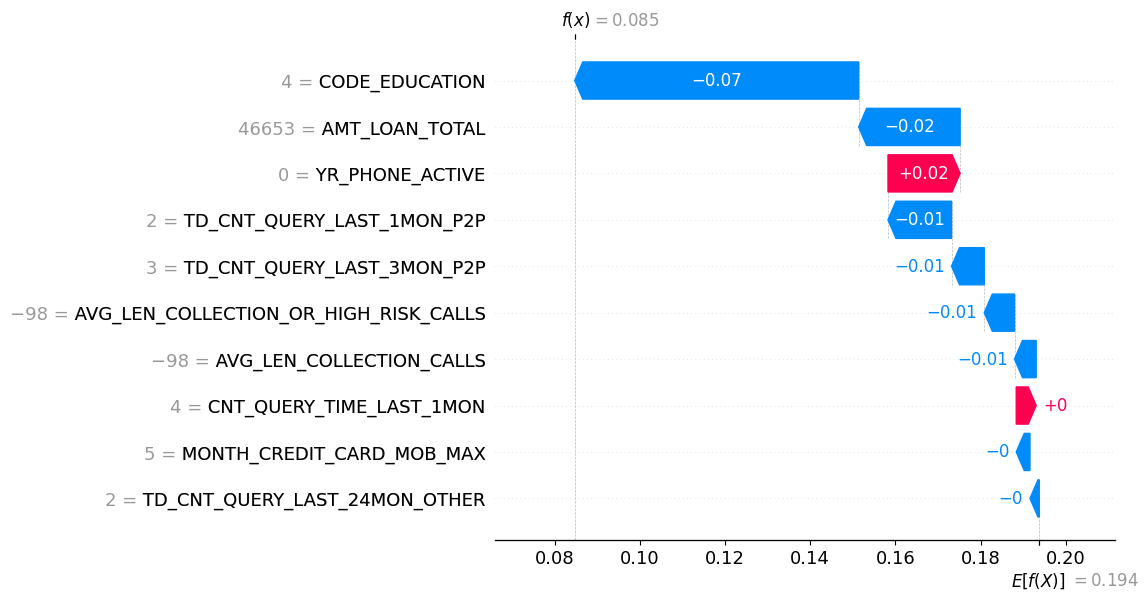

In [287]:
shap.plots.waterfall(rf_shap_values[1]) 

**Waterfall Plot 2 (f(x) = 0.085):**

Here, the base value of 19.4% dropped significantly to 8.6%. The biggest reductions came from CODE_EDUCATION = 4 (-0.06), AMT_LOAN_TOTAL = 46653 (-0.02), and TD_CNT_QUERY_LAST_1MON_P2P = 2 (-0.02). Positive influence came only from YR_PHONE_ACTIVE = 0 (+0.02), indicating that shorter phone activity history slightly increased the predicted risk, but overall, the strong negative contributions dominated.

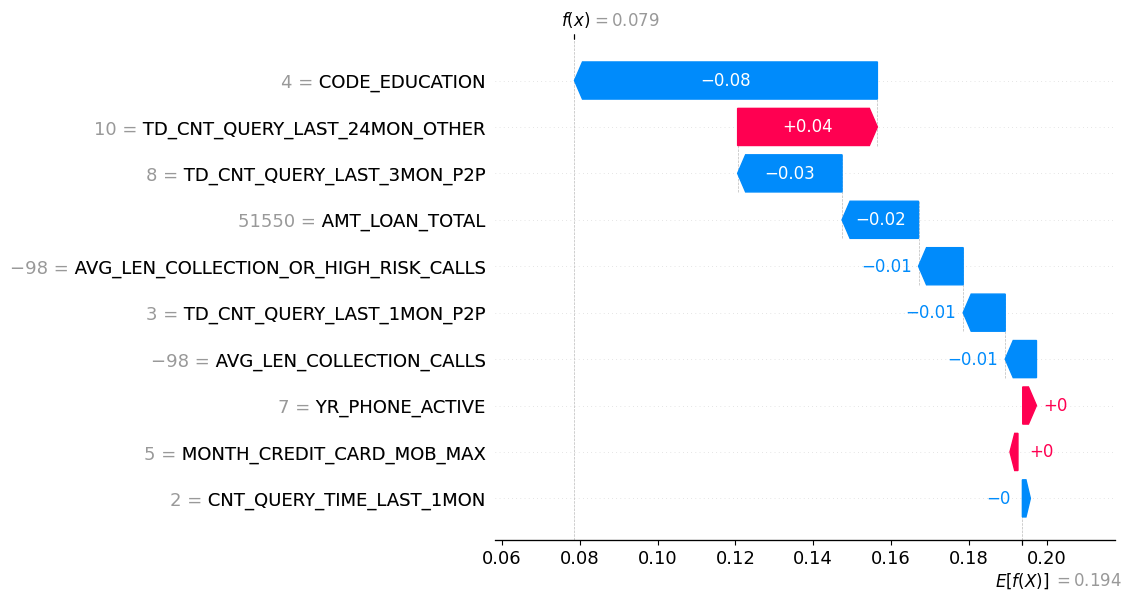

In [288]:
shap.plots.waterfall(rf_shap_values[2]) 

**Waterfall Plot 3 (f(x) = 0.079):**

Starting from the 19.4% base, the prediction again dropped to 8.5%. The largest drop was due to CODE_EDUCATION = 4 (-0.08), followed by moderate reductions from TD_CNT_QUERY_LAST_3MON_P2P = 8 (-0.02) and TD_CNT_QUERY_LAST_1MON_P2P = 3 (-0.01). The only meaningful positive push came from TD_CNT_QUERY_LAST_24MON_OTHER = 10 (+0.03), indicating that more past inquiries in the last 24 months increased the risk, but still not enough to offset the education-related reduction.

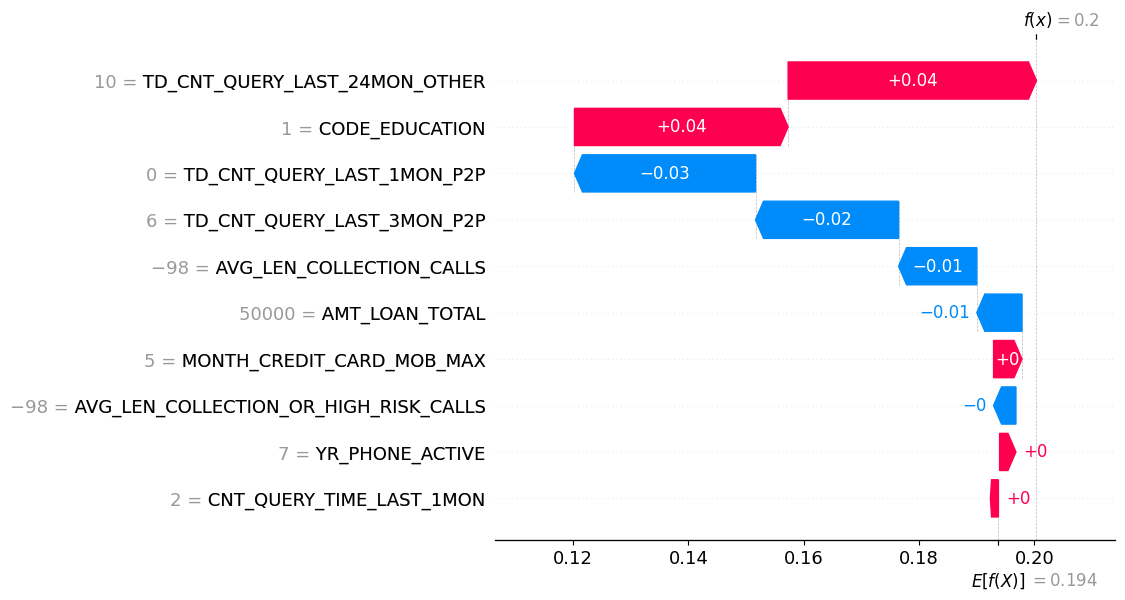

In [289]:
shap.plots.waterfall(rf_shap_values[3]) 

**Waterfall Plot 4 (f(x) = 0.2):**

This case stays closer to the base value, ending at 18.7%. Positive impacts from TD_CNT_QUERY_LAST_24MON_OTHER = 10 (+0.04) and CODE_EDUCATION = 1 (+0.04) drove the score up, indicating higher risk for applicants with low education and more long-term inquiries. These were balanced by negatives from TD_CNT_QUERY_LAST_1MON_P2P = 0 (-0.04) and TD_CNT_QUERY_LAST_3MON_P2P = 6 (-0.03), which reduced the score slightly.

### Conclusion

Through the SHAP analysis, we identified the most influential factors driving the Random Forest model’s predictions, such as CODE_EDUCATION, TD_CNT_QUERY_LAST_1MON_P2P, TD_CNT_QUERY_LAST_3MON_P2P, and AVG_LEN_COLLECTION_CALLS. The global plots confirmed that these features consistently contributed to higher or lower predicted default probabilities across the dataset, while the dependence plots revealed the nuanced relationships and interactions between them. At the individual level, the force and waterfall plots provided detailed, case-by-case breakdowns showing how each feature’s value influenced the prediction relative to the model’s base probability (0.194). This dual-level analysis — combining global interpretability and local explanations — offers a transparent and actionable understanding of the model’s decision process. Such insights are crucial for improving model trust, guiding business strategy, and ensuring fair and explainable credit decisions.